In [1]:
from neuralprophet import NeuralProphet
NeuralProphet()

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
import sys
import os

# Ajouter la racine du projet au PYTHONPATH
sys.path.append(os.path.abspath("../.."))

import pandas as pd
from src.prediction.time_series import train_prophet, forecast_prophet


# Charger le dataset d'exemple
df = pd.read_csv("../../data/examples/urgences_exemple.csv")

# Convertir la colonne datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Vérifier la structure
df.head()

,datetime,arrivals
0,2024-01-01 00:00:00,16.0
1,2024-01-01 01:00:00,15.0
2,2024-01-01 02:00:00,16.0
3,2024-01-01 03:00:00,18.0
4,2024-01-01 04:00:00,15.0


In [3]:
import pandas as pd
from neuralprophet import NeuralProphet

def train_prophet(df: pd.DataFrame, date_col: str, target_col: str):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model

def train_prophet(df, date_col, target_col):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model, model_df

def forecast_prophet(model, df, periods: int, freq: str = "H"):
    future = model.make_future_dataframe(
        df=df,
        periods=periods,
        n_historic_predictions=True
    )
    forecast = model.predict(future)
    return forecast


In [4]:
import inspect
print(inspect.signature(forecast_prophet))



(model, df, periods: int, freq: str = 'H')


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (N

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (34) is too small than the required number                     for the learning rate finder (233). The results might not be optimal.


Finding best initial lr:   0%|          | 0/233 [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\pytorch_lightning\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\pytorch_lightning\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 49. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.954% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1173: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_ts = pd.DataFrame(pd.date_range("1994-01-01", periods=100, freq=freq_str))

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


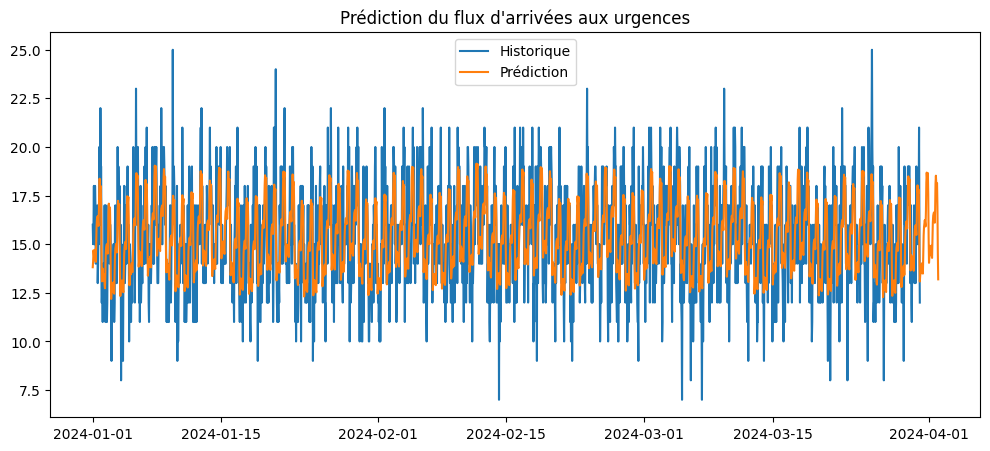

In [5]:
import matplotlib.pyplot as plt

model, model_df = train_prophet(df, "datetime", "arrivals")
forecast = forecast_prophet(model=model, df=model_df, periods=48)
#forecast.head()
#forecast.columns

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["arrivals"], label="Historique")
plt.plot(forecast["ds"], forecast["yhat1"], label="Prédiction")
plt.legend()
plt.title("Prédiction du flux d'arrivées aux urgences")
plt.show()


In [6]:
import numpy as np
import pandas as pd

mu = 20.0  # à ajuster selon ta réalité

# On part de ton forecast existant
mm1 = forecast.copy()
mm1["lambda"] = mm1["yhat1"]          # arrivées prédites par heure
mm1["rho"] = mm1["lambda"] / mu       # taux d'occupation

# On force la stabilité : on ignore (ou marque) les heures où lambda >= mu
mm1["stable"] = mm1["lambda"] < mu

# Formules M/M/1 (là où c'est stable)
mm1.loc[mm1["stable"], "Lq"] = (mm1["rho"]**2 / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "L"]  = (mm1["rho"] / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "Wq"] = mm1["Lq"][mm1["stable"]] / mm1["lambda"][mm1["stable"]]
mm1.loc[mm1["stable"], "W"]  = mm1["L"][mm1["stable"]]  / mm1["lambda"][mm1["stable"]]

In [7]:
mm1["stable"].value_counts()

stable
True    2209
Name: count, dtype: int64

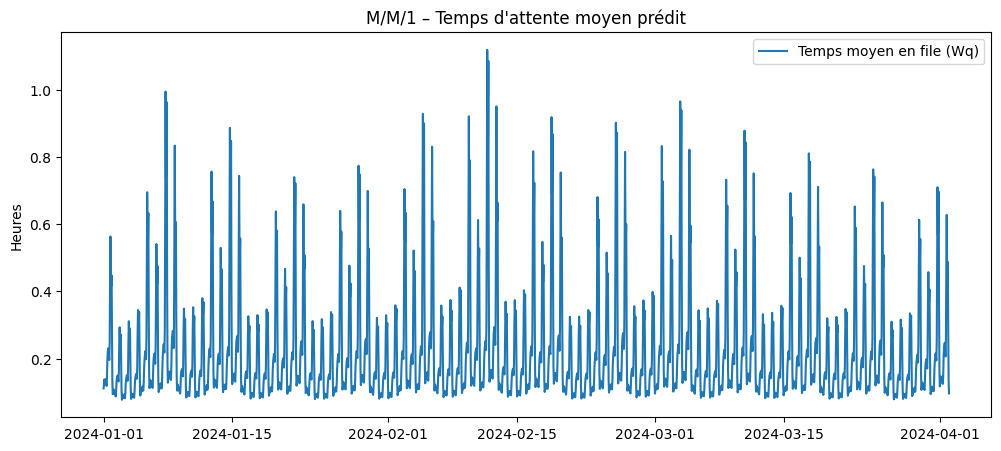

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mm1["ds"], mm1["Wq"], label="Temps moyen en file (Wq)")
plt.ylabel("Heures")
plt.legend()
plt.title("M/M/1 – Temps d'attente moyen prédit")
plt.show()

In [9]:
import numpy as np
import pandas as pd

mu_doc = 3.3  # patients/heure par médecin (estimé)
c_values = [3, 4, 5, 6, 7]  # scénarios de nombre de médecins

lambda_t = forecast["yhat1"].values  # arrivées prédites par heure
ds = forecast["ds"].values

def mmc_metrics(lmbda, mu_doc, c):
    mu_tot = c * mu_doc
    rho = lmbda / mu_tot  # taux d'occupation global

    if lmbda == 0:
        return rho, 0.0  # pas d'arrivées, pas d'attente

    a = lmbda / mu_doc  # charge offerte

    # Calcul de P0 (probabilité que le système soit vide)
    sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))
    last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

    if rho >= 1:
        return rho, np.inf  # système instable

    P0 = 1.0 / (sum_terms + last_term)

    # Probabilité qu'un patient attende (Erlang C)
    Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

    # Temps moyen en file (Wq)
    Wq = Pc / (c * mu_doc - lmbda)  # en heures

    return rho, Wq

# On construit un DataFrame avec un Wq par scénario de c
mmc = pd.DataFrame({"ds": ds, "lambda": lambda_t})

for c in c_values:
    rhos = []
    wqs = []
    for lmbda in lambda_t:
        rho, Wq = mmc_metrics(lmbda, mu_doc, c)
        rhos.append(rho)
        wqs.append(Wq)
    mmc[f"rho_c{c}"] = rhos
    mmc[f"Wq_c{c}"] = wqs


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.i

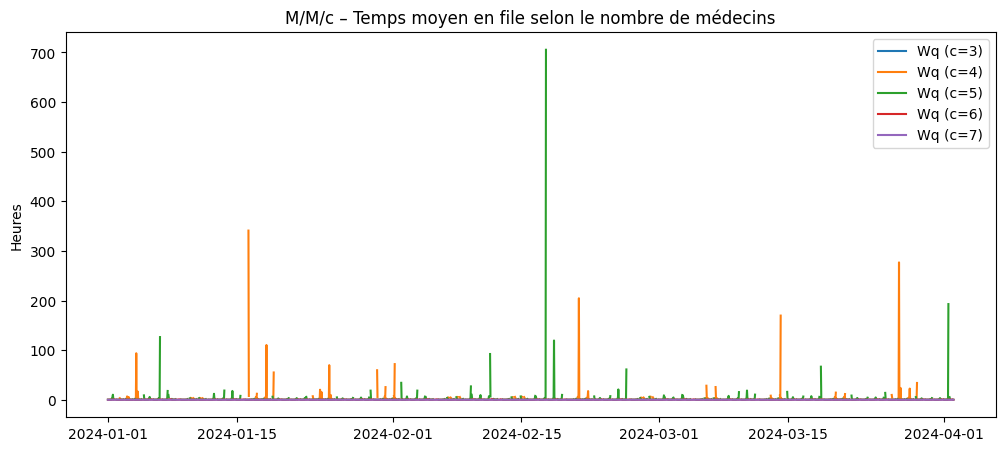

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for c in c_values:
    plt.plot(mmc["ds"], mmc[f"Wq_c{c}"], label=f"Wq (c={c})")
plt.ylabel("Heures")
plt.title("M/M/c – Temps moyen en file selon le nombre de médecins")
plt.legend()
plt.show()

In [10]:
Wq_target = 0.5  # 30 minutes

results = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    # proportion d'heures où le temps d'attente est sous le seuil
    pct_ok = (Wq < Wq_target).mean() * 100
    results.append((c, pct_ok))

results


[(3, 0.0),
 (4, 0.0),
 (5, 46.49162516976007),
 (6, 92.25894069714803),
 (7, 100.0)]

In [11]:
optimal = None
for c, pct in results:
    if pct >= 95:   # objectif : 95% des heures sous 30 minutes
        optimal = c
        break

optimal

7

In [12]:
import pandas as pd

df_results = pd.DataFrame(results, columns=["Médecins (c)", "% heures Wq < 30 min"])
df_results

,Médecins (c),% heures Wq < 30 min
0,3,0.000000
1,4,0.000000
2,5,46.491625
3,6,92.258941
4,7,100.000000


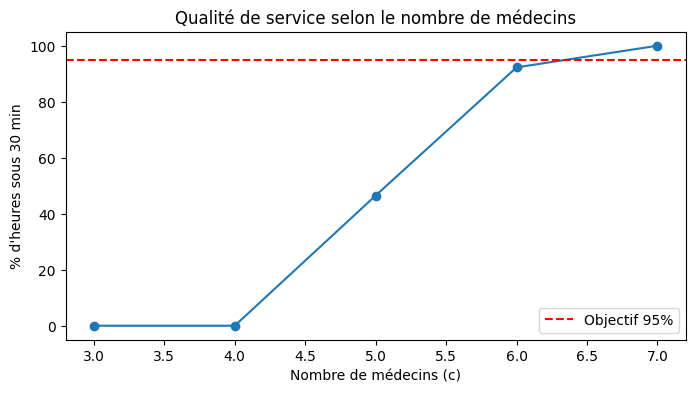

In [13]:
plt.figure(figsize=(8,4))
plt.plot(df_results["Médecins (c)"], df_results["% heures Wq < 30 min"], marker="o")
plt.axhline(95, color="red", linestyle="--", label="Objectif 95%")
plt.ylabel("% d'heures sous 30 min")
plt.xlabel("Nombre de médecins (c)")
plt.title("Qualité de service selon le nombre de médecins")
plt.legend()
plt.show()

In [14]:
Wq_target = 0.25  # 15 minutes

results_15 = []

for c in c_values:
    Wq = mmc[f"Wq_c{c}"]
    pct_ok = (Wq < Wq_target).mean() * 100
    results_15.append((c, pct_ok))

results_15

[(3, 0.0),
 (4, 0.0),
 (5, 26.392032593933905),
 (6, 81.75645088275238),
 (7, 100.0)]

In [15]:
optimal_15 = None
for c, pct in results_15:
    if pct >= 95:   # objectif : 95% des heures sous 15 minutes
        optimal_15 = c
        break

optimal_15


7

In [16]:
def optimal_c_per_hour(lambda_t, mu_doc, Wq_target=0.5, c_max=12):
    for c in range(1, c_max+1):
        rho, Wq = mmc_metrics(lambda_t, mu_doc, c)
        if Wq < Wq_target:
            return c
    return c_max  # si jamais aucun c ne suffit

mmc["c_opt_30min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.5)
    for lmbda in mmc["lambda"]
]

mmc["c_opt_15min"] = [
    optimal_c_per_hour(lmbda, mu_doc, Wq_target=0.25)
    for lmbda in mmc["lambda"]
]

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARNING

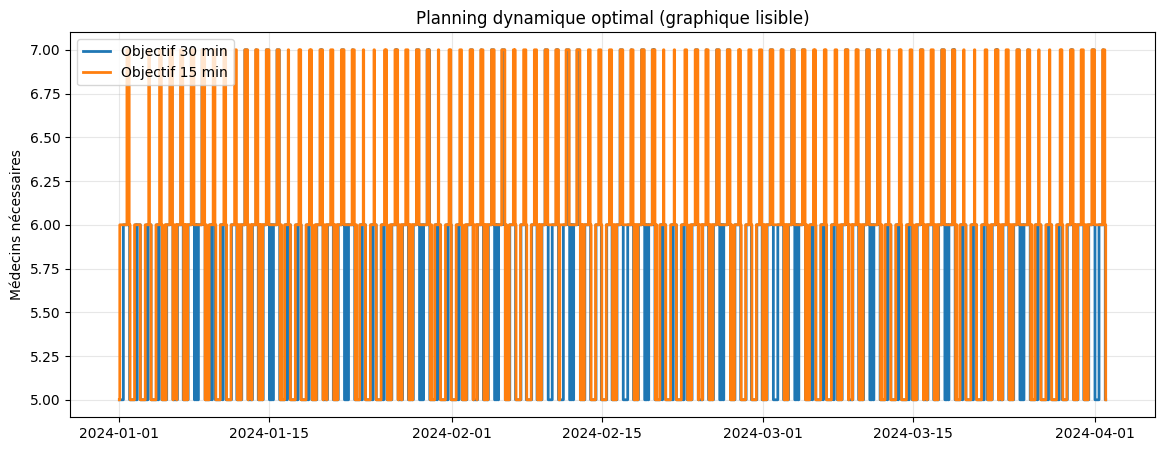

In [17]:
#plt.figure(figsize=(12,5))
#plt.plot(mmc["ds"], mmc["c_opt_30min"], label="Objectif 30 min")
#plt.plot(mmc["ds"], mmc["c_opt_15min"], label="Objectif 15 min")
#plt.ylabel("Médecins nécessaires")
#plt.title("Planning dynamique optimal")
#plt.legend()
#plt.show()

plt.figure(figsize=(14, 5))

plt.step(mmc["ds"], mmc["c_opt_30min"], where="post", label="Objectif 30 min", linewidth=2)
plt.step(mmc["ds"], mmc["c_opt_15min"], where="post", label="Objectif 15 min", linewidth=2)

plt.ylabel("Médecins nécessaires")
plt.title("Planning dynamique optimal (graphique lisible)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [18]:
import pandas as pd

def compress_schedule(times, values):
    """
    Regroupe les périodes consécutives où la valeur reste identique.
    """
    segments = []
    start = times[0]
    current_value = values[0]

    for i in range(1, len(times)):
        if values[i] != current_value:
            segments.append((start, times[i-1], current_value))
            start = times[i]
            current_value = values[i]

    # dernier segment
    segments.append((start, times.iloc[-1], current_value))
    return segments

# Création des segments pour les deux objectifs
segments_30 = compress_schedule(mmc["ds"], mmc["c_opt_30min"])
segments_15 = compress_schedule(mmc["ds"], mmc["c_opt_15min"])

# Fusion des deux plannings
rows = []
for (s30, e30, v30), (_, _, v15) in zip(segments_30, segments_15):
    rows.append({
        "Début": s30,
        "Fin": e30,
        "Médecins (30 min)": v30,
        "Médecins (15 min)": v15
    })

planning_df = pd.DataFrame(rows)
planning_df


,Début,Fin,Médecins (30 min),Médecins (15 min)
0,2024-01-01 00:00:00,2024-01-01 08:00:00,5,5
1,2024-01-01 09:00:00,2024-01-01 17:00:00,6,6
2,2024-01-01 18:00:00,2024-01-01 18:00:00,7,7
3,2024-01-01 19:00:00,2024-01-01 22:00:00,6,6
4,2024-01-01 23:00:00,2024-01-02 11:00:00,5,5
...,...,...,...,...
398,2024-04-01 00:00:00,2024-04-01 08:00:00,5,5
399,2024-04-01 09:00:00,2024-04-01 17:00:00,6,6
400,2024-04-01 18:00:00,2024-04-01 18:00:00,7,7
401,2024-04-01 19:00:00,2024-04-01 22:00:00,6,6


In [19]:
# Résumé par jour
daily_summary = mmc.groupby(mmc["ds"].dt.date).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

daily_summary.columns = ["Date", "Médecins (30 min)", "Médecins (15 min)"]
daily_summary

,Date,Médecins (30 min),Médecins (15 min)
0,2024-01-01,7,7
1,2024-01-02,6,6
2,2024-01-03,6,7
3,2024-01-04,6,7
4,2024-01-05,7,7
...,...,...,...
88,2024-03-29,7,7
89,2024-03-30,6,7
90,2024-03-31,7,7
91,2024-04-01,7,7


In [20]:
mmc["week"] = mmc["ds"].dt.isocalendar().week

weekly_summary = mmc.groupby("week").agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

weekly_summary.columns = ["Semaine", "Médecins (30 min)", "Médecins (15 min)"]
weekly_summary


,Semaine,Médecins (30 min),Médecins (15 min)
0,1,7,7
1,2,7,7
2,3,7,7
3,4,7,7
4,5,7,7
5,6,7,7
6,7,7,7
7,8,7,7
8,9,7,7
9,10,7,7


In [21]:
def zone_color(c):
    if c <= 5:
        return "🟢 Creuse"
    elif c == 6:
        return "🟡 Normale"
    else:
        return "🔴 Pointe"

daily_summary["Zone (30 min)"] = daily_summary["Médecins (30 min)"].apply(zone_color)
daily_summary["Zone (15 min)"] = daily_summary["Médecins (15 min)"].apply(zone_color)

daily_summary


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe
1,2024-01-02,6,6,🟡 Normale,🟡 Normale
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe
...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe


In [22]:
cost_doc = 80
cost_wait = 20

def total_cost(lmbda, mu_doc, c):
    rho, Wq = mmc_metrics(lmbda, mu_doc, c)
    return c * cost_doc + lmbda * Wq * cost_wait

mmc["cost_30min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_30min"])
]

mmc["cost_15min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_15min"])
]

daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

WARNING

,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,12832.787047,12709.242887
1,2024-01-02,11791.967740,11733.048942
2,2024-01-03,11735.598329,11660.657692
3,2024-01-04,11881.347028,11837.823306
4,2024-01-05,12455.530355,12418.487955
...,...,...,...
88,2024-03-29,12454.615793,12313.482940
89,2024-03-30,12499.663492,12445.437549
90,2024-03-31,12470.478460,12456.061776
91,2024-04-01,13115.084054,12815.535503


In [23]:
daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]
daily_cost


,Date,Coût total (30 min),Coût total (15 min)
0,2024-01-01,12832.787047,12709.242887
1,2024-01-02,11791.967740,11733.048942
2,2024-01-03,11735.598329,11660.657692
3,2024-01-04,11881.347028,11837.823306
4,2024-01-05,12455.530355,12418.487955
...,...,...,...
88,2024-03-29,12454.615793,12313.482940
89,2024-03-30,12499.663492,12445.437549
90,2024-03-31,12470.478460,12456.061776
91,2024-04-01,13115.084054,12815.535503


In [25]:
# Résumé par jour
daily_summary = mmc.groupby(mmc["ds"].dt.date).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

daily_summary.columns = ["Date", "Médecins (30 min)", "Médecins (15 min)"]
daily_summary


,Date,Médecins (30 min),Médecins (15 min)
0,2024-01-01,7,7
1,2024-01-02,6,6
2,2024-01-03,6,7
3,2024-01-04,6,7
4,2024-01-05,7,7
...,...,...,...
88,2024-03-29,7,7
89,2024-03-30,6,7
90,2024-03-31,7,7
91,2024-04-01,7,7


In [26]:
mmc["week"] = mmc["ds"].dt.isocalendar().week

weekly_summary = mmc.groupby("week").agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max"
}).reset_index()

weekly_summary.columns = ["Semaine", "Médecins (30 min)", "Médecins (15 min)"]
weekly_summary


,Semaine,Médecins (30 min),Médecins (15 min)
0,1,7,7
1,2,7,7
2,3,7,7
3,4,7,7
4,5,7,7
5,6,7,7
6,7,7,7
7,8,7,7
8,9,7,7
9,10,7,7


In [27]:
def zone_color(c):
    if c <= 5:
        return "🟢 Creuse"
    elif c == 6:
        return "🟡 Normale"
    else:
        return "🔴 Pointe"

daily_summary["Zone (30 min)"] = daily_summary["Médecins (30 min)"].apply(zone_color)
daily_summary["Zone (15 min)"] = daily_summary["Médecins (15 min)"].apply(zone_color)


In [29]:
cost_doc = 80
cost_wait = 20

def total_cost(lmbda, mu_doc, c):
    rho, Wq = mmc_metrics(lmbda, mu_doc, c)
    return c * cost_doc + lmbda * Wq * cost_wait

mmc["cost_30min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_30min"])
]

mmc["cost_15min"] = [
    total_cost(lmbda, mu_doc, c)
    for lmbda, c in zip(mmc["lambda"], mmc["c_opt_15min"])
]

daily_cost = mmc.groupby(mmc["ds"].dt.date).agg({
    "cost_30min": "sum",
    "cost_15min": "sum"
}).reset_index()

daily_cost.columns = ["Date", "Coût total (30 min)", "Coût total (15 min)"]

full_daily = daily_summary.merge(daily_cost, on="Date")
full_daily


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_6700\3328086401.py:29: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0



,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955
...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13115.084054,12815.535503


In [ ]:
full_daily["Surcoût (15 min vs 30 min)"] = (
    full_daily["Coût total (15 min)"] - full_daily["Coût total (30 min)"]
)

full_daily["Gain de qualité (médecins)"] = (
    full_daily["Médecins (15 min)"] - full_daily["Médecins (30 min)"]
)

full_daily

,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942,-58.918798,0
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692,-74.940638,1
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306,-43.523722,1
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955,-37.042400,0
...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940,-141.132852,0
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549,-54.225943,1
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776,-14.416684,0
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13115.084054,12815.535503,-299.548551,0


In [31]:
full_daily[["Date", "Surcoût (15 min vs 30 min)", "Gain de qualité (médecins)"]]

,Date,Surcoût (15 min vs 30 min),Gain de qualité (médecins)
0,2024-01-01,-123.544160,0
1,2024-01-02,-58.918798,0
2,2024-01-03,-74.940638,1
3,2024-01-04,-43.523722,1
4,2024-01-05,-37.042400,0
...,...,...,...
88,2024-03-29,-141.132852,0
89,2024-03-30,-54.225943,1
90,2024-03-31,-14.416684,0
91,2024-04-01,-299.548551,0


In [32]:
day = pd.to_datetime("2024-01-03").date()
df_day = mmc[mmc["ds"].dt.date == day]

df_day[["ds", "lambda", "c_opt_30min", "c_opt_15min", "Wq_c6", "Wq_c7"]]


,ds,lambda,c_opt_30min,c_opt_15min,Wq_c6,Wq_c7
48,2024-01-03 00:00:00,12.185456,5,5,0.028274,0.008822
49,2024-01-03 01:00:00,12.448257,5,5,0.031586,0.009908
50,2024-01-03 02:00:00,13.010285,5,5,0.039901,0.012607
51,2024-01-03 03:00:00,12.785282,5,5,0.036353,0.011460
52,2024-01-03 04:00:00,12.564743,5,5,0.033164,0.010423
53,2024-01-03 05:00:00,12.935995,5,5,0.038695,0.012218
54,2024-01-03 06:00:00,13.033665,5,5,0.040288,0.012731
55,2024-01-03 07:00:00,12.558468,5,5,0.033077,0.010395
56,2024-01-03 08:00:00,12.456449,5,5,0.031694,0.009943
57,2024-01-03 09:00:00,13.362642,5,5,0.046128,0.014597


In [33]:
jours_insuffisants = full_daily[full_daily["Surcoût (15 min vs 30 min)"] < 0]
jours_insuffisants


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942,-58.918798,0
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692,-74.940638,1
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306,-43.523722,1
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955,-37.042400,0
...,...,...,...,...,...,...,...,...,...
87,2024-03-28,6,7,🟡 Normale,🔴 Pointe,11820.841046,11782.178637,-38.662408,1
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940,-141.132852,0
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549,-54.225943,1
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776,-14.416684,0


In [34]:
jours_surdimensionnes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 0) &
    (full_daily["Surcoût (15 min vs 30 min)"] > 0)
]
jours_surdimensionnes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins)
11,2024-01-12,7,7,🔴 Pointe,🔴 Pointe,12486.899532,12536.945015,50.045483,0
13,2024-01-14,7,7,🔴 Pointe,🔴 Pointe,12612.104028,12645.433830,33.329802,0
27,2024-01-28,7,7,🔴 Pointe,🔴 Pointe,12482.394223,12531.928569,49.534346,0
34,2024-02-04,7,7,🔴 Pointe,🔴 Pointe,12633.683328,12657.857097,24.173768,0
39,2024-02-09,7,7,🔴 Pointe,🔴 Pointe,12666.273247,12680.897044,14.623797,0
41,2024-02-11,7,7,🔴 Pointe,🔴 Pointe,12827.258208,12867.669186,40.410978,0
46,2024-02-16,7,7,🔴 Pointe,🔴 Pointe,12572.276868,12596.774692,24.497825,0
48,2024-02-18,7,7,🔴 Pointe,🔴 Pointe,12645.756942,12666.171030,20.414089,0
55,2024-02-25,7,7,🔴 Pointe,🔴 Pointe,12610.763084,12616.167869,5.404786,0
60,2024-03-01,7,7,🔴 Pointe,🔴 Pointe,12581.079068,12599.956213,18.877145,0


In [39]:
mmc["rho"] = mmc["lambda"] / (mmc["c_opt_30min"] * mu_doc)

rho_daily = mmc.groupby(mmc["ds"].dt.date)["rho"].mean().reset_index()
rho_daily.columns = ["Date", "Rho moyen"]

full_daily = full_daily.merge(rho_daily, on="Date")

jours_satures = full_daily[full_daily["Rho moyen"] > 0.85]
jours_satures


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12767.601303,12637.182304,-130.418999,0,0.853391,0.853391,<NA>,-8.694600,0.853391
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,12781.482266,12642.008540,-139.473726,0,0.854132,0.854132,<NA>,-9.298248,0.854132
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13125.474997,12843.562029,-281.912969,0,0.853292,0.853292,<NA>,-18.794198,0.853292
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12724.877633,12623.628406,-101.249228,0,0.851872,0.851872,<NA>,-6.749949,0.851872
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12999.277614,12800.756289,-198.521325,0,0.853859,0.853859,<NA>,-13.234755,0.853859
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12871.043566,12720.777865,-150.265701,0,0.857559,0.857559,<NA>,-10.017713,0.857559
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12930.987357,12736.671116,-194.316241,0,0.859563,0.859563,<NA>,-12.954416,0.859563
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12746.608175,12630.058666,-116.549509,0,0.852806,0.852806,<NA>,-7.769967,0.852806
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12697.362632,12566.301093,-131.061539,1,0.853751,0.853751,-131.061539,-8.737436,0.853751


In [40]:
full_daily["Coût marginal par médecin"] = (
    full_daily["Surcoût (15 min vs 30 min)"] /
    full_daily["Gain de qualité (médecins)"].replace(0, pd.NA)
)

full_daily["Coût marginal par minute gagnée"] = (
    full_daily["Surcoût (15 min vs 30 min)"] / 15
)

In [41]:
jours_sous_staffes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 1) &
    (full_daily["Surcoût (15 min vs 30 min)"] < 0) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_sous_staffes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12697.362632,12566.301093,-131.061539,1,0.853751,0.853751,-131.061539,-8.737436,0.853751


In [42]:
jours_7_insuffisant = full_daily[
    (full_daily["Médecins (30 min)"] == 7) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_7_insuffisant

,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12767.601303,12637.182304,-130.418999,0,0.853391,0.853391,<NA>,-8.694600,0.853391
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,12781.482266,12642.008540,-139.473726,0,0.854132,0.854132,<NA>,-9.298248,0.854132
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13125.474997,12843.562029,-281.912969,0,0.853292,0.853292,<NA>,-18.794198,0.853292
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12724.877633,12623.628406,-101.249228,0,0.851872,0.851872,<NA>,-6.749949,0.851872
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12999.277614,12800.756289,-198.521325,0,0.853859,0.853859,<NA>,-13.234755,0.853859
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12871.043566,12720.777865,-150.265701,0,0.857559,0.857559,<NA>,-10.017713,0.857559
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12930.987357,12736.671116,-194.316241,0,0.859563,0.859563,<NA>,-12.954416,0.859563
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12746.608175,12630.058666,-116.549509,0,0.852806,0.852806,<NA>,-7.769967,0.852806
84,2024-03-25,7,7,🔴 Pointe,🔴 Pointe,13163.713487,12855.228029,-308.485458,0,0.854638,0.854638,<NA>,-20.565697,0.854638


In [44]:
def c_for_rho(lambda_t, mu_doc, rho_target=0.75, c_max=12):
    for c in range(1, c_max+1):
        rho = lambda_t / (c * mu_doc)
        if rho < rho_target:
            return c
    return c_max

mmc["c_opt_rho75"] = [
    c_for_rho(lmbda, mu_doc)
    for lmbda in mmc["lambda"]
]

daily_rho75 = mmc.groupby(mmc["ds"].dt.date)["c_opt_rho75"].max().reset_index()
daily_rho75.columns = ["Date", "Médecins nécessaires (rho<0.75)"]
daily_rho75


,Date,Médecins nécessaires (rho<0.75)
0,2024-01-01,8
1,2024-01-02,7
2,2024-01-03,7
3,2024-01-04,8
4,2024-01-05,8
...,...,...
88,2024-03-29,8
89,2024-03-30,8
90,2024-03-31,8
91,2024-04-01,8


In [45]:
tableau_final = full_daily.merge(daily_rho75, on="Date")
tableau_final


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen,Médecins nécessaires (rho<0.75)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942,-58.918798,0,0.822522,0.822522,<NA>,-3.927920,0.822522,7
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692,-74.940638,1,0.817295,0.817295,-74.940638,-4.996043,0.817295,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306,-43.523722,1,0.821023,0.821023,-43.523722,-2.901581,0.821023,8
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955,-37.042400,0,0.822493,0.822493,<NA>,-2.469493,0.822493,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940,-141.132852,0,0.825858,0.825858,<NA>,-9.408857,0.825858,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549,-54.225943,1,0.845632,0.845632,-54.225943,-3.615063,0.845632,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776,-14.416684,0,0.823640,0.823640,<NA>,-0.961112,0.823640,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13115.084054,12815.535503,-299.548551,0,0.862710,0.862710,<NA>,-19.969903,0.862710,8


In [46]:
jours_sous_staffes = full_daily[
    (full_daily["Gain de qualité (médecins)"] == 1) &
    (full_daily["Surcoût (15 min vs 30 min)"] < 0) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_sous_staffes


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12697.362632,12566.301093,-131.061539,1,0.853751,0.853751,-131.061539,-8.737436,0.853751


In [47]:
jours_7_insuffisant = full_daily[
    (full_daily["Médecins (30 min)"] == 7) &
    (full_daily["Rho moyen"] > 0.85)
]
jours_7_insuffisant


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12767.601303,12637.182304,-130.418999,0,0.853391,0.853391,<NA>,-8.694600,0.853391
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,12781.482266,12642.008540,-139.473726,0,0.854132,0.854132,<NA>,-9.298248,0.854132
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13125.474997,12843.562029,-281.912969,0,0.853292,0.853292,<NA>,-18.794198,0.853292
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12724.877633,12623.628406,-101.249228,0,0.851872,0.851872,<NA>,-6.749949,0.851872
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12999.277614,12800.756289,-198.521325,0,0.853859,0.853859,<NA>,-13.234755,0.853859
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12871.043566,12720.777865,-150.265701,0,0.857559,0.857559,<NA>,-10.017713,0.857559
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12930.987357,12736.671116,-194.316241,0,0.859563,0.859563,<NA>,-12.954416,0.859563
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12746.608175,12630.058666,-116.549509,0,0.852806,0.852806,<NA>,-7.769967,0.852806
84,2024-03-25,7,7,🔴 Pointe,🔴 Pointe,13163.713487,12855.228029,-308.485458,0,0.854638,0.854638,<NA>,-20.565697,0.854638


In [48]:
def c_for_rho(lambda_t, mu_doc, rho_target=0.75, c_max=12):
    for c in range(1, c_max+1):
        rho = lambda_t / (c * mu_doc)
        if rho < rho_target:
            return c
    return c_max

mmc["c_opt_rho75"] = [
    c_for_rho(lmbda, mu_doc)
    for lmbda in mmc["lambda"]
]

daily_rho75 = mmc.groupby(mmc["ds"].dt.date)["c_opt_rho75"].max().reset_index()
daily_rho75.columns = ["Date", "Médecins nécessaires (rho<0.75)"]
daily_rho75


,Date,Médecins nécessaires (rho<0.75)
0,2024-01-01,8
1,2024-01-02,7
2,2024-01-03,7
3,2024-01-04,8
4,2024-01-05,8
...,...,...
88,2024-03-29,8
89,2024-03-30,8
90,2024-03-31,8
91,2024-04-01,8


In [49]:
tableau_final = full_daily.merge(daily_rho75, on="Date")
tableau_final


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen,Médecins nécessaires (rho<0.75)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942,-58.918798,0,0.822522,0.822522,<NA>,-3.927920,0.822522,7
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692,-74.940638,1,0.817295,0.817295,-74.940638,-4.996043,0.817295,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306,-43.523722,1,0.821023,0.821023,-43.523722,-2.901581,0.821023,8
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955,-37.042400,0,0.822493,0.822493,<NA>,-2.469493,0.822493,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940,-141.132852,0,0.825858,0.825858,<NA>,-9.408857,0.825858,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549,-54.225943,1,0.845632,0.845632,-54.225943,-3.615063,0.845632,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776,-14.416684,0,0.823640,0.823640,<NA>,-0.961112,0.823640,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13115.084054,12815.535503,-299.548551,0,0.862710,0.862710,<NA>,-19.969903,0.862710,8


In [50]:
tableau_final[tableau_final["Médecins nécessaires (rho<0.75)"] > tableau_final["Médecins (30 min)"]]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen,Médecins nécessaires (rho<0.75)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776,8
1,2024-01-02,6,6,🟡 Normale,🟡 Normale,11791.967740,11733.048942,-58.918798,0,0.822522,0.822522,<NA>,-3.927920,0.822522,7
2,2024-01-03,6,7,🟡 Normale,🔴 Pointe,11735.598329,11660.657692,-74.940638,1,0.817295,0.817295,-74.940638,-4.996043,0.817295,7
3,2024-01-04,6,7,🟡 Normale,🔴 Pointe,11881.347028,11837.823306,-43.523722,1,0.821023,0.821023,-43.523722,-2.901581,0.821023,8
4,2024-01-05,7,7,🔴 Pointe,🔴 Pointe,12455.530355,12418.487955,-37.042400,0,0.822493,0.822493,<NA>,-2.469493,0.822493,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7,7,🔴 Pointe,🔴 Pointe,12454.615793,12313.482940,-141.132852,0,0.825858,0.825858,<NA>,-9.408857,0.825858,8
89,2024-03-30,6,7,🟡 Normale,🔴 Pointe,12499.663492,12445.437549,-54.225943,1,0.845632,0.845632,-54.225943,-3.615063,0.845632,8
90,2024-03-31,7,7,🔴 Pointe,🔴 Pointe,12470.478460,12456.061776,-14.416684,0,0.823640,0.823640,<NA>,-0.961112,0.823640,8
91,2024-04-01,7,7,🔴 Pointe,🔴 Pointe,13115.084054,12815.535503,-299.548551,0,0.862710,0.862710,<NA>,-19.969903,0.862710,8


In [51]:
tableau_final[
    (tableau_final["Gain de qualité (médecins)"] == 0) &
    (tableau_final["Surcoût (15 min vs 30 min)"] > 0)
]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen,Médecins nécessaires (rho<0.75)
11,2024-01-12,7,7,🔴 Pointe,🔴 Pointe,12486.899532,12536.945015,50.045483,0,0.823110,0.823110,<NA>,3.336366,0.823110,8
13,2024-01-14,7,7,🔴 Pointe,🔴 Pointe,12612.104028,12645.433830,33.329802,0,0.831092,0.831092,<NA>,2.221987,0.831092,8
27,2024-01-28,7,7,🔴 Pointe,🔴 Pointe,12482.394223,12531.928569,49.534346,0,0.823008,0.823008,<NA>,3.302290,0.823008,8
34,2024-02-04,7,7,🔴 Pointe,🔴 Pointe,12633.683328,12657.857097,24.173768,0,0.832274,0.832274,<NA>,1.611585,0.832274,8
39,2024-02-09,7,7,🔴 Pointe,🔴 Pointe,12666.273247,12680.897044,14.623797,0,0.833871,0.833871,<NA>,0.974920,0.833871,8
41,2024-02-11,7,7,🔴 Pointe,🔴 Pointe,12827.258208,12867.669186,40.410978,0,0.842605,0.842605,<NA>,2.694065,0.842605,8
46,2024-02-16,7,7,🔴 Pointe,🔴 Pointe,12572.276868,12596.774692,24.497825,0,0.828617,0.828617,<NA>,1.633188,0.828617,8
48,2024-02-18,7,7,🔴 Pointe,🔴 Pointe,12645.756942,12666.171030,20.414089,0,0.833055,0.833055,<NA>,1.360939,0.833055,8
55,2024-02-25,7,7,🔴 Pointe,🔴 Pointe,12610.763084,12616.167869,5.404786,0,0.830894,0.830894,<NA>,0.360319,0.830894,8
60,2024-03-01,7,7,🔴 Pointe,🔴 Pointe,12581.079068,12599.956213,18.877145,0,0.828993,0.828993,<NA>,1.258476,0.828993,8


In [52]:
tableau_final[tableau_final["Rho moyen"] > 0.85]


,Date,Médecins (30 min),Médecins (15 min),Zone (30 min),Zone (15 min),Coût total (30 min),Coût total (15 min),Surcoût (15 min vs 30 min),Gain de qualité (médecins),Rho moyen_x,Rho moyen_y,Coût marginal par médecin,Coût marginal par minute gagnée,Rho moyen,Médecins nécessaires (rho<0.75)
0,2024-01-01,7,7,🔴 Pointe,🔴 Pointe,12832.787047,12709.242887,-123.544160,0,0.852776,0.852776,<NA>,-8.236277,0.852776,8
5,2024-01-06,7,7,🔴 Pointe,🔴 Pointe,12767.601303,12637.182304,-130.418999,0,0.853391,0.853391,<NA>,-8.694600,0.853391,8
12,2024-01-13,7,7,🔴 Pointe,🔴 Pointe,12781.482266,12642.008540,-139.473726,0,0.854132,0.854132,<NA>,-9.298248,0.854132,8
21,2024-01-22,7,7,🔴 Pointe,🔴 Pointe,13125.474997,12843.562029,-281.912969,0,0.853292,0.853292,<NA>,-18.794198,0.853292,8
33,2024-02-03,7,7,🔴 Pointe,🔴 Pointe,12724.877633,12623.628406,-101.249228,0,0.851872,0.851872,<NA>,-6.749949,0.851872,8
40,2024-02-10,7,7,🔴 Pointe,🔴 Pointe,12999.277614,12800.756289,-198.521325,0,0.853859,0.853859,<NA>,-13.234755,0.853859,8
47,2024-02-17,7,7,🔴 Pointe,🔴 Pointe,12871.043566,12720.777865,-150.265701,0,0.857559,0.857559,<NA>,-10.017713,0.857559,8
61,2024-03-02,7,7,🔴 Pointe,🔴 Pointe,12930.987357,12736.671116,-194.316241,0,0.859563,0.859563,<NA>,-12.954416,0.859563,8
68,2024-03-09,7,7,🔴 Pointe,🔴 Pointe,12746.608175,12630.058666,-116.549509,0,0.852806,0.852806,<NA>,-7.769967,0.852806,8
75,2024-03-16,6,7,🟡 Normale,🔴 Pointe,12697.362632,12566.301093,-131.061539,1,0.853751,0.853751,-131.061539,-8.737436,0.853751,8


In [53]:
def time_block(dt):
    h = dt.hour
    if 0 <= h < 8:
        return "Nuit (00–08)"
    elif 8 <= h < 12:
        return "Matin (08–12)"
    elif 12 <= h < 16:
        return "Midi (12–16)"
    elif 16 <= h < 20:
        return "Après‑midi (16–20)"
    else:
        return "Soir (20–00)"

mmc["block"] = mmc["ds"].apply(time_block)

planning_blocs = mmc.groupby([mmc["ds"].dt.date, "block"]).agg({
    "c_opt_30min": "max",
    "c_opt_15min": "max",
    "rho": "mean"
}).reset_index()

planning_blocs.columns = ["Date", "Plage horaire", "Médecins (30 min)", "Médecins (15 min)", "Rho moyen"]
planning_blocs


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen
0,2024-01-01,Après‑midi (16–20),7,7,0.862158
1,2024-01-01,Matin (08–12),6,6,0.809483
2,2024-01-01,Midi (12–16),6,6,0.819789
3,2024-01-01,Nuit (00–08),5,6,0.870195
4,2024-01-01,Soir (20–00),6,7,0.884839
...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.819310
457,2024-04-01,Midi (12–16),6,6,0.828606
458,2024-04-01,Nuit (00–08),5,6,0.883337
459,2024-04-01,Soir (20–00),6,7,0.891896


In [54]:
planning_pivot = planning_blocs.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

planning_pivot


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00)
0,2024-01-01,7.0,6.0,6.0,5.0,6.0
1,2024-01-02,6.0,5.0,6.0,5.0,6.0
2,2024-01-03,6.0,5.0,6.0,5.0,6.0
3,2024-01-04,6.0,5.0,6.0,5.0,6.0
4,2024-01-05,7.0,6.0,6.0,5.0,7.0
...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0
89,2024-03-30,6.0,6.0,6.0,5.0,6.0
90,2024-03-31,7.0,6.0,6.0,5.0,7.0
91,2024-04-01,7.0,6.0,6.0,5.0,6.0


In [55]:
plages_critiques = planning_blocs[
    (planning_blocs["Rho moyen"] > 0.85) |
    (planning_blocs["Médecins (30 min)"] >= 7)
]
plages_critiques


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen
0,2024-01-01,Après‑midi (16–20),7,7,0.862158
3,2024-01-01,Nuit (00–08),5,6,0.870195
4,2024-01-01,Soir (20–00),6,7,0.884839
12,2024-01-03,Midi (12–16),6,6,0.860174
19,2024-01-04,Soir (20–00),6,7,0.858824
...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.841860
454,2024-03-31,Soir (20–00),7,7,0.817039
455,2024-04-01,Après‑midi (16–20),7,7,0.869777
458,2024-04-01,Nuit (00–08),5,6,0.883337


In [56]:
planning_optimal = planning_blocs.copy()

def commentaire(row):
    if row["Rho moyen"] > 0.85:
        return "⚠️ Système saturé — renfort nécessaire"
    if row["Médecins (15 min)"] > row["Médecins (30 min)"]:
        return "👍 Ajouter 1 médecin améliore la qualité"
    if row["Médecins (30 min)"] >= 7:
        return "🔴 Forte activité"
    if row["Médecins (30 min)"] <= 5:
        return "🟢 Activité faible"
    return "🟡 Activité normale"

planning_optimal["Commentaire"] = planning_optimal.apply(commentaire, axis=1)
planning_optimal


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),7,7,0.862158,⚠️ Système saturé — renfort nécessaire
1,2024-01-01,Matin (08–12),6,6,0.809483,🟡 Activité normale
2,2024-01-01,Midi (12–16),6,6,0.819789,🟡 Activité normale
3,2024-01-01,Nuit (00–08),5,6,0.870195,⚠️ Système saturé — renfort nécessaire
4,2024-01-01,Soir (20–00),6,7,0.884839,⚠️ Système saturé — renfort nécessaire
...,...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.819310,🟡 Activité normale
457,2024-04-01,Midi (12–16),6,6,0.828606,🟡 Activité normale
458,2024-04-01,Nuit (00–08),5,6,0.883337,⚠️ Système saturé — renfort nécessaire
459,2024-04-01,Soir (20–00),6,7,0.891896,⚠️ Système saturé — renfort nécessaire


In [57]:
planning_journalier = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00)
0,2024-01-01,7.0,6.0,6.0,5.0,6.0
1,2024-01-02,6.0,5.0,6.0,5.0,6.0
2,2024-01-03,6.0,5.0,6.0,5.0,6.0
3,2024-01-04,6.0,5.0,6.0,5.0,6.0
4,2024-01-05,7.0,6.0,6.0,5.0,7.0
...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0
89,2024-03-30,6.0,6.0,6.0,5.0,6.0
90,2024-03-31,7.0,6.0,6.0,5.0,7.0
91,2024-04-01,7.0,6.0,6.0,5.0,6.0


In [58]:
commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(commentaires, on="Date", suffixes=("", " (commentaire)"))
planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
1,2024-01-02,6.0,5.0,6.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,⚠️ Système saturé — renfort nécessaire
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [59]:
commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(commentaires, on="Date", suffixes=("", " (commentaire)"))
planning_journalier


Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
1,2024-01-02,6.0,5.0,6.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,⚠️ Système saturé — renfort nécessaire,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,⚠️ Système saturé — renfort nécessaire
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [60]:
jours_a_renforcer = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]["Date"].unique()

jours_a_renforcer


array([datetime.date(2024, 1, 1), datetime.date(2024, 1, 3),
       datetime.date(2024, 1, 4), datetime.date(2024, 1, 5),
       datetime.date(2024, 1, 6), datetime.date(2024, 1, 7),
       datetime.date(2024, 1, 8), datetime.date(2024, 1, 10),
       datetime.date(2024, 1, 11), datetime.date(2024, 1, 12),
       datetime.date(2024, 1, 13), datetime.date(2024, 1, 14),
       datetime.date(2024, 1, 15), datetime.date(2024, 1, 18),
       datetime.date(2024, 1, 19), datetime.date(2024, 1, 20),
       datetime.date(2024, 1, 21), datetime.date(2024, 1, 22),
       datetime.date(2024, 1, 25), datetime.date(2024, 1, 26),
       datetime.date(2024, 1, 27), datetime.date(2024, 1, 28),
       datetime.date(2024, 1, 29), datetime.date(2024, 2, 1),
       datetime.date(2024, 2, 2), datetime.date(2024, 2, 3),
       datetime.date(2024, 2, 4), datetime.date(2024, 2, 5),
       datetime.date(2024, 2, 6), datetime.date(2024, 2, 7),
       datetime.date(2024, 2, 8), datetime.date(2024, 2, 9),
       d

In [61]:
plages_critiques = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]
plages_critiques

,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),7,7,0.862158,⚠️ Système saturé — renfort nécessaire
3,2024-01-01,Nuit (00–08),5,6,0.870195,⚠️ Système saturé — renfort nécessaire
4,2024-01-01,Soir (20–00),6,7,0.884839,⚠️ Système saturé — renfort nécessaire
12,2024-01-03,Midi (12–16),6,6,0.860174,⚠️ Système saturé — renfort nécessaire
19,2024-01-04,Soir (20–00),6,7,0.858824,⚠️ Système saturé — renfort nécessaire
...,...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.841860,🔴 Forte activité
454,2024-03-31,Soir (20–00),7,7,0.817039,🔴 Forte activité
455,2024-04-01,Après‑midi (16–20),7,7,0.869777,⚠️ Système saturé — renfort nécessaire
458,2024-04-01,Nuit (00–08),5,6,0.883337,⚠️ Système saturé — renfort nécessaire


In [62]:
def commentaire(row):
    if row["Rho moyen"] > 0.85:
        return "⚠️ Système saturé — renfort nécessaire"
    if row["Médecins (15 min)"] > row["Médecins (30 min)"]:
        return "👍 Ajouter 1 médecin améliore la qualité"
    if row["Médecins (30 min)"] >= 7:
        return "🔴 Forte activité"
    if row["Médecins (30 min)"] <= 5:
        return "🟢 Activité faible"
    return "🟡 Activité normale"

planning_optimal = planning_blocs.copy()
planning_optimal["Commentaire"] = planning_optimal.apply(commentaire, axis=1)

planning_optimal


,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),7,7,0.862158,⚠️ Système saturé — renfort nécessaire
1,2024-01-01,Matin (08–12),6,6,0.809483,🟡 Activité normale
2,2024-01-01,Midi (12–16),6,6,0.819789,🟡 Activité normale
3,2024-01-01,Nuit (00–08),5,6,0.870195,⚠️ Système saturé — renfort nécessaire
4,2024-01-01,Soir (20–00),6,7,0.884839,⚠️ Système saturé — renfort nécessaire
...,...,...,...,...,...,...
456,2024-04-01,Matin (08–12),6,6,0.819310,🟡 Activité normale
457,2024-04-01,Midi (12–16),6,6,0.828606,🟡 Activité normale
458,2024-04-01,Nuit (00–08),5,6,0.883337,⚠️ Système saturé — renfort nécessaire
459,2024-04-01,Soir (20–00),6,7,0.891896,⚠️ Système saturé — renfort nécessaire


In [63]:
planning_journalier = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Médecins (30 min)",
    aggfunc="max"
).reset_index()

commentaires = planning_optimal.pivot_table(
    index="Date",
    columns="Plage horaire",
    values="Commentaire",
    aggfunc="first"
).reset_index()

planning_journalier = planning_journalier.merge(
    commentaires,
    on="Date",
    suffixes=("", " (commentaire)")
)

planning_journalier

Plage horaire,Date,Après‑midi (16–20),Matin (08–12),Midi (12–16),Nuit (00–08),Soir (20–00),Après‑midi (16–20) (commentaire),Matin (08–12) (commentaire),Midi (12–16) (commentaire),Nuit (00–08) (commentaire),Soir (20–00) (commentaire)
0,2024-01-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
1,2024-01-02,6.0,5.0,6.0,5.0,6.0,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,🟡 Activité normale
2,2024-01-03,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,⚠️ Système saturé — renfort nécessaire,🟢 Activité faible,🟡 Activité normale
3,2024-01-04,6.0,5.0,6.0,5.0,6.0,👍 Ajouter 1 médecin améliore la qualité,👍 Ajouter 1 médecin améliore la qualité,🟡 Activité normale,🟢 Activité faible,⚠️ Système saturé — renfort nécessaire
4,2024-01-05,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
...,...,...,...,...,...,...,...,...,...,...,...
88,2024-03-29,7.0,6.0,6.0,5.0,7.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,🟢 Activité faible,🔴 Forte activité
89,2024-03-30,6.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire
90,2024-03-31,7.0,6.0,6.0,5.0,7.0,🔴 Forte activité,🟡 Activité normale,🟡 Activité normale,👍 Ajouter 1 médecin améliore la qualité,🔴 Forte activité
91,2024-04-01,7.0,6.0,6.0,5.0,6.0,⚠️ Système saturé — renfort nécessaire,🟡 Activité normale,🟡 Activité normale,⚠️ Système saturé — renfort nécessaire,⚠️ Système saturé — renfort nécessaire


In [64]:
plages_critiques = planning_optimal[
    (planning_optimal["Rho moyen"] > 0.85) |
    (planning_optimal["Médecins (30 min)"] >= 7)
]

plages_critiques

,Date,Plage horaire,Médecins (30 min),Médecins (15 min),Rho moyen,Commentaire
0,2024-01-01,Après‑midi (16–20),7,7,0.862158,⚠️ Système saturé — renfort nécessaire
3,2024-01-01,Nuit (00–08),5,6,0.870195,⚠️ Système saturé — renfort nécessaire
4,2024-01-01,Soir (20–00),6,7,0.884839,⚠️ Système saturé — renfort nécessaire
12,2024-01-03,Midi (12–16),6,6,0.860174,⚠️ Système saturé — renfort nécessaire
19,2024-01-04,Soir (20–00),6,7,0.858824,⚠️ Système saturé — renfort nécessaire
...,...,...,...,...,...,...
450,2024-03-31,Après‑midi (16–20),7,7,0.841860,🔴 Forte activité
454,2024-03-31,Soir (20–00),7,7,0.817039,🔴 Forte activité
455,2024-04-01,Après‑midi (16–20),7,7,0.869777,⚠️ Système saturé — renfort nécessaire
458,2024-04-01,Nuit (00–08),5,6,0.883337,⚠️ Système saturé — renfort nécessaire


In [ ]:
planning_optimal.to_csv("planning_optimal.csv", index=False)
planning_journalier.to_csv("planning_journalier.csv", index=False)
plages_critiques.to_csv("plages_critiques.csv", index=False)

In [71]:
planning_optimal.to_excel("planning_optimal.xlsx", index=False)
planning_journalier.to_excel("planning_journalier.xlsx", index=False)
plages_critiques.to_excel("plages_critiques.xlsx", index=False)